# Image Search

This example shows how SentenceTransformer can be used to map images and texts to the same vector space. 

As model, we use the [OpenAI CLIP Model](https://github.com/openai/CLIP), which was trained on a large set of images and image alt texts.  
Note that the CLIP is now from 2021 and more recent models exist. We use it for this illustration because it is small and therefore run on a Google Colab GPU.  
As an alternative, you can check the models with the [`zero-shot-image-classification`](https://huggingface.co/models?pipeline_tag=zero-shot-image-classification) pipeline tag on the 🤗 Hub.  
You can also test [trimmed](https://huggingface.co/blog/lbourdois/introduction-to-trimming) models that have the advantage of being smaller than the models from which they are derived while keeping the same performance. To find these models, we invite you to look at the `visual embedding` models listed in this [Space](https://huggingface.co/spaces/alphaedge-ai/Trimming_models_search).

As a source for photos, we use the [Unsplash Dataset Lite](https://unsplash.com/data), which contains about 25k images. See the [License](https://unsplash.com/license) about the Unsplash images. 

Note: 25k images is rather small. If you search for really specific terms, the chance are high that no such photo exist in the collection.

In [1]:
import torch
from datasets import load_dataset
from IPython.display import display
from PIL import Image

from sentence_transformers import SentenceTransformer
from sentence_transformers.util import semantic_search

c:\Users\tom\.conda\envs\sentence-transformers\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
W0601 13:37:19.724000 36576 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


## clip-ViT-B-32

### Text-to-Image Search

In [2]:
# First, we load the CLIP model
model = SentenceTransformer("sentence-transformers/clip-ViT-B-32")

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 8619.65it/s]


In [3]:
# Next, we load the Unsplash Dataset Lite
unsplash = load_dataset("sentence-transformers/unsplash-lite")

# We can see that the dataset contains a column containing the images
# but also a column containing keywords that we will not use here.
unsplash

DatasetDict({
    train: Dataset({
        features: ['image', 'keywords'],
        num_rows: 24996
    })
})

In [4]:
# Now, we need to compute the embeddings
# The attached function will be required for the following cell
# in the case where precomputed embeddings are not used.
embeddings_name = "embeddings_clip-ViT-B-32"


def embed(batch):
    """
    adds to the dataset a column of embeddings of images calculated with the model
    """
    image = batch["image"]
    return {embeddings_name: model.encode(image, convert_to_tensor=True)}

In [5]:
# Here for the calculation of the embeddings, you have 2 choices:
# 1) `use_precomputed_embeddings = True` and in that case you can
# use embeddings that we have already pre-calculated in order to speed up
# the execution of the notebook.
# 2) `use_precomputed_embeddings = False` and compute the embeddings on the fly.
# Takes about 9 minutes on a Google Colab T4

use_precomputed_embeddings = True

if use_precomputed_embeddings:
    embeddings_ds = load_dataset("sentence-transformers/unsplash-lite", name=embeddings_name, split="train")
    unsplash["train"] = unsplash["train"].add_column(embeddings_name, embeddings_ds[embeddings_name])

else:
    unsplash = unsplash.map(embed, batched=True, batch_size=16)

    # Uncomment the rest of the else condition if you want to save the embeddings
    # on the Hub to use `use_precomputed_embeddings = True` in the future

    # # We delete 'image' and 'keywords' so as not to save them as duplicates unnecessarily
    # embeddings_ds = unsplash['train'].remove_columns(['image', 'keywords'])
    # embeddings_ds.push_to_hub(
    #     "your_username/unsplash-lite", # your username
    #     config_name=embeddings_name,
    #     split="train",
    #     token="hf_xx" # your HF token
    # )

# We now have a new column containing our embeddings, which we load as a tensor
img_emb = torch.tensor(unsplash["train"][embeddings_name])
unsplash

DatasetDict({
    train: Dataset({
        features: ['image', 'keywords', 'embeddings_clip-ViT-B-32'],
        num_rows: 24996
    })
})

In [6]:
# Next, we define a search function.
def search(query, k=3):
    # First, we encode the query (which can either be an image or a text string)
    query_emb = model.encode_query([query], convert_to_tensor=True, show_progress_bar=False)
    hits = semantic_search(query_emb, img_emb, top_k=k)[0]

    # Managing Query Display
    print("Query:")
    if isinstance(query, str):
        # If it's text, it's displayed normally
        print(f'"{query}"')
    elif isinstance(query, Image.Image):
        # If it's a PIL image, resize it so that it doesn't take up the entire screen
        query_display = query.copy()
        query_display.thumbnail((200, 200))
        display(query_display)
    else:
        # Default case in case
        display(query)

    for hit in hits:
        # Numerical index
        idx = hit["corpus_id"]
        # Associated similarity score
        score = hit["score"]
        print(f"Score: {score:.4f} (Index: {idx})")

        # We use the index to access the dataset
        image_data = unsplash["train"][idx]
        img = image_data["image"]

        # Rescaled to fit the screen
        width = 200
        height = int(width * img.height / img.width)
        display(img.resize((width, height)))

Query:
"A sunset on the beach"
Score: 0.3030 (Index: 23337)


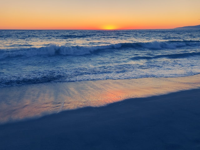

Score: 0.3015 (Index: 20095)


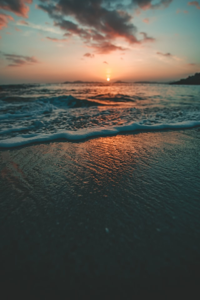

Score: 0.3012 (Index: 7808)


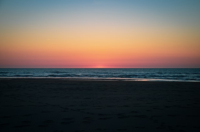

In [7]:
search("A sunset on the beach")

Query:
"A beach with palm trees"
Score: 0.3164 (Index: 3434)


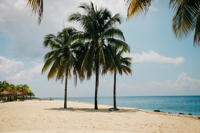

Score: 0.3127 (Index: 19023)


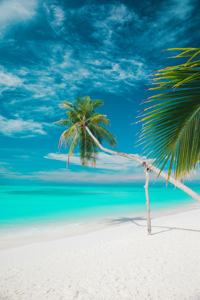

Score: 0.3120 (Index: 14439)


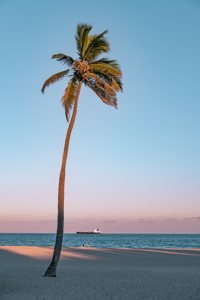

In [8]:
search("A beach with palm trees")

Query:
"London"
Score: 0.2752 (Index: 22194)


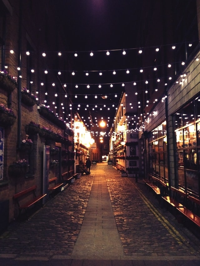

Score: 0.2725 (Index: 11310)


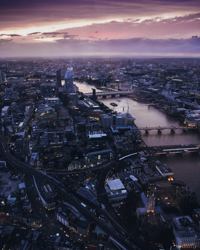

Score: 0.2699 (Index: 12393)


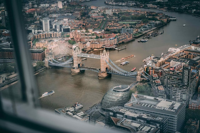

In [9]:
search("London")

### Image-to-Image Search
You can use the method also for image-to-image search.
It will then return similar images.

Query:


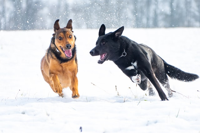

Score: 1.0000 (Index: 6267)


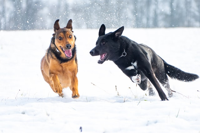

Score: 0.8913 (Index: 23529)


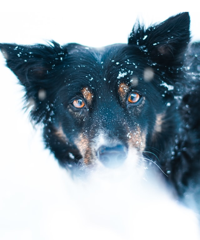

Score: 0.8668 (Index: 21659)


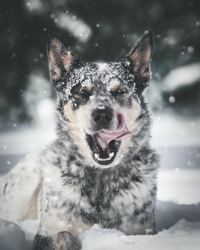

Score: 0.8663 (Index: 12696)


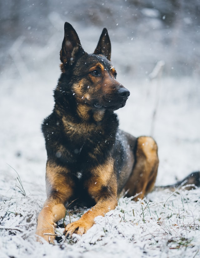

Score: 0.8633 (Index: 6551)


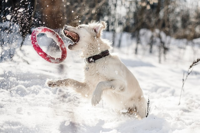

In [10]:
search(unsplash["train"][6267]["image"], k=5)

## metaclip-2 worldwide s16

### Text-to-Image Search

In [11]:
# Import model
model = SentenceTransformer("facebook/metaclip-2-worldwide-s16-384")

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 8929.16it/s]


In [12]:
# Embeddings column name
embeddings_name = "embeddings_metaclip-2-worldwide-s16-384"

In [13]:
# Here for the calculation of the embeddings, you have 2 choices:
# 1) `use_precomputed_embeddings = True` and in that case you can
# use embeddings that we have already pre-calculated in order to speed up
# the execution of the notebook.
# 2) `use_precomputed_embeddings = False` and compute the embeddings on the fly.
# Takes about 20 minutes on a Google Colab T4

use_precomputed_embeddings = True

if use_precomputed_embeddings:
    embeddings_ds = load_dataset("sentence-transformers/unsplash-lite", name=embeddings_name, split="train")
    unsplash["train"] = unsplash["train"].add_column(embeddings_name, embeddings_ds[embeddings_name])

else:
    unsplash = unsplash.map(embed, batched=True, batch_size=16)

    # Uncomment the rest of the else condition if you want to save the embeddings
    # on the Hub to use `use_precomputed_embeddings = True` in the future

    # # We delete 'image' and 'keywords' so as not to save them as duplicates unnecessarily
    # embeddings_ds = unsplash['train'].remove_columns(['image', 'keywords'])
    # embeddings_ds.push_to_hub(
    #     "your_username/unsplash-lite", # your username
    #     config_name=embeddings_name,
    #     split="train",
    #     token="hf_xx" # your HF token
    # )

# We now have a new column containing our embeddings, which we load as a tensor
img_emb = torch.tensor(unsplash["train"][embeddings_name])

Generating train split: 100%|██████████| 24996/24996 [00:00<00:00, 328024.28 examples/s]


Query:
"A sunset on the beach"
Score: 0.2336 (Index: 21949)


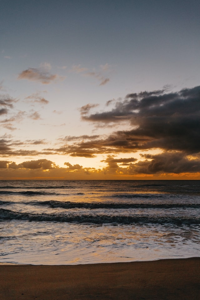

Score: 0.2336 (Index: 7808)


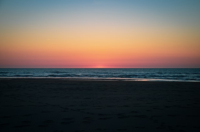

Score: 0.2333 (Index: 23337)


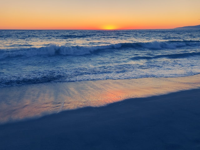

In [14]:
search("A sunset on the beach")

Query:
"A beach with palm trees"
Score: 0.2606 (Index: 18490)


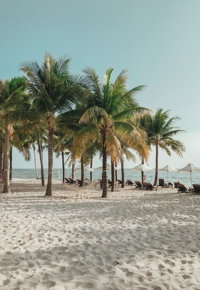

Score: 0.2557 (Index: 17181)


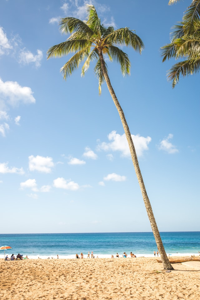

Score: 0.2541 (Index: 21595)


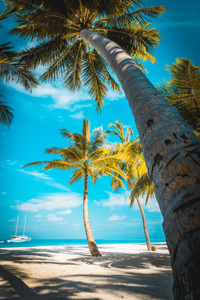

In [15]:
search("A beach with palm trees")

Query:
"London"
Score: 0.2258 (Index: 11420)


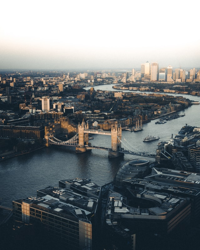

Score: 0.2197 (Index: 24718)


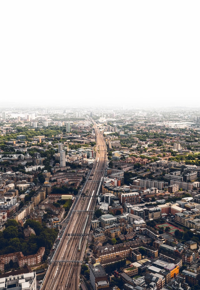

Score: 0.2193 (Index: 11310)


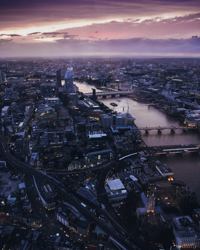

In [16]:
search("London")

### Image-to-Image Search

Query:


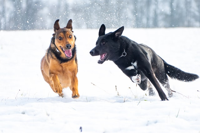

Score: 1.0000 (Index: 6267)


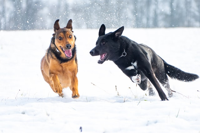

Score: 0.8862 (Index: 12696)


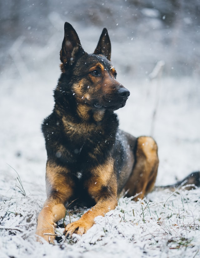

Score: 0.8567 (Index: 18656)


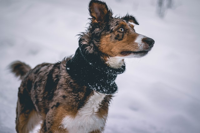

Score: 0.8558 (Index: 19459)


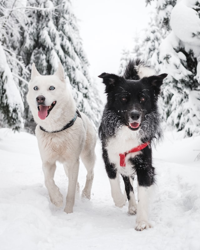

Score: 0.8467 (Index: 17465)


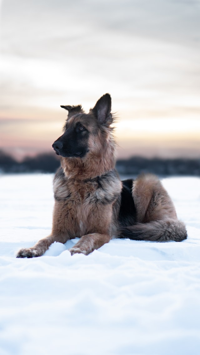

In [17]:
search(unsplash["train"][6267]["image"], k=5)

## metaclip-2 worldwide s16 trimmed

The results (whether images or confidence scores), will be exactly the same as for metaclip-2 worldwide s16 but the model will only have 56M parameters compared to 390M previously.

### Text-to-Image Search

In [18]:
# Import model
model = SentenceTransformer("alphaedge-ai/metaclip-2-worldwide-s16-384-eng-32768")

[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 32767), got 49406. This may result in unexpected behavior.
Loading weights: 100%|██████████| 398/398 [00:00<00:00, 9186.85it/s]


In [19]:
# Embeddings column name
embeddings_name = "embeddings_metaclip-2-worldwide-s16-384-eng-32768"

In [20]:
# Here for the calculation of the embeddings, you have 2 choices:
# 1) `use_precomputed_embeddings = True` and in that case you can
# use embeddings that we have already pre-calculated in order to speed up
# the execution of the notebook.
# 2) `use_precomputed_embeddings = False` and compute the embeddings on the fly.
# Takes about 20 minutes on a Google Colab T4

use_precomputed_embeddings = True

if use_precomputed_embeddings:
    embeddings_ds = load_dataset("sentence-transformers/unsplash-lite", name=embeddings_name, split="train")
    unsplash["train"] = unsplash["train"].add_column(embeddings_name, embeddings_ds[embeddings_name])

else:
    unsplash = unsplash.map(embed, batched=True, batch_size=16)

    # Uncomment the rest of the else condition if you want to save the embeddings
    # on the Hub to use `use_precomputed_embeddings = True` in the future

    # # We delete 'image' and 'keywords' so as not to save them as duplicates unnecessarily
    # embeddings_ds = unsplash['train'].remove_columns(['image', 'keywords'])
    # embeddings_ds.push_to_hub(
    #     "your_username/unsplash-lite", # your username
    #     config_name=embeddings_name,
    #     split="train",
    #     token="hf_xx" # your HF token
    # )

# We now have a new column containing our embeddings, which we load as a tensor
img_emb = torch.tensor(unsplash["train"][embeddings_name])

Generating train split: 100%|██████████| 24996/24996 [00:00<00:00, 398729.82 examples/s]


Query:
"A sunset on the beach"
Score: 0.2336 (Index: 21949)


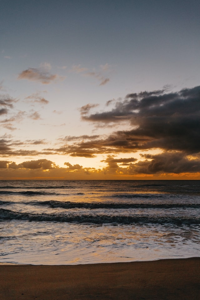

Score: 0.2336 (Index: 7808)


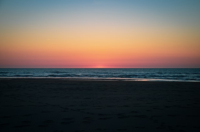

Score: 0.2333 (Index: 23337)


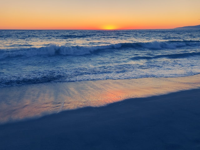

In [21]:
search("A sunset on the beach")

Query:
"A beach with palm trees"
Score: 0.2606 (Index: 18490)


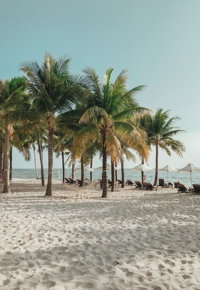

Score: 0.2557 (Index: 17181)


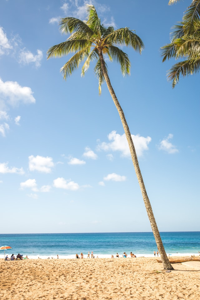

Score: 0.2541 (Index: 21595)


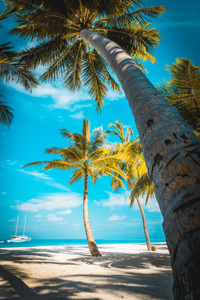

In [22]:
search("A beach with palm trees")

Query:
"London"
Score: 0.2258 (Index: 11420)


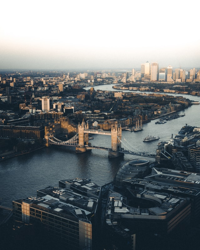

Score: 0.2197 (Index: 24718)


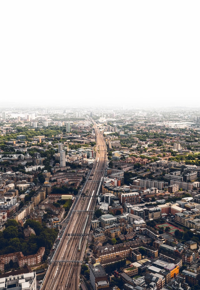

Score: 0.2193 (Index: 11310)


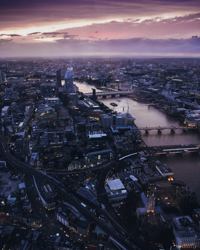

In [23]:
search("London")

### Image-to-Image Search

Query:


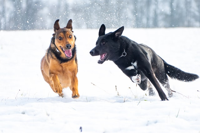

Score: 1.0000 (Index: 6267)


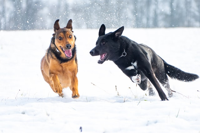

Score: 0.8862 (Index: 12696)


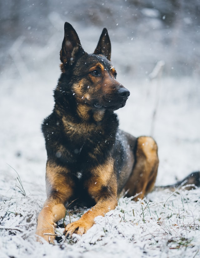

Score: 0.8567 (Index: 18656)


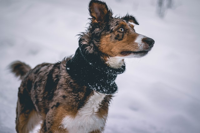

Score: 0.8558 (Index: 19459)


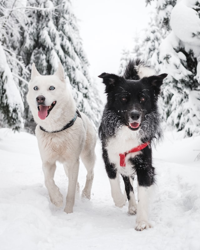

Score: 0.8467 (Index: 17465)


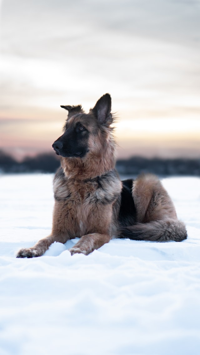

In [24]:
search(unsplash["train"][6267]["image"], k=5)